In [2]:
import pandas as pd

file_path = "test_features_windows/features_49_60_ALL_WINDOWS_features_new_SCR.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)
print(df.shape)

          HR  HRV_RMSSD   HRV_SDNN     RR_mean     RR_std  RR_min  RR_max  \
0  81.081141  42.045893  78.031333  735.000000  76.969632   325.0   835.0   
1  81.326360  41.866189  77.395825  736.315789  76.370670   325.0   835.0   
2  81.558277  41.816846  76.383329  736.538462  75.397696   325.0   835.0   
3  81.827108  40.793413  74.633250  737.682927  73.717470   325.0   835.0   
4  80.391178  42.727521  34.265180  744.500000  33.834154   670.0   835.0   

   RR_count  RR_diff_std  RR_valid  SCR_Rate  participant  time_sec  \
0        37    41.991253         1  0.095310           49         0   
1        38    41.851442         1  0.064539           49         1   
2        39    41.760911         1  0.064539           49         2   
3        41    40.764393         1  0.064539           49         3   
4        40    42.554061         1  0.032790           49         4   

   EDA_Tonic_log  EDA_Phasic_log  
0            6.0        2.000000  
1            6.0        1.691600  
2    

In [6]:
features = [
    'HR',
    'HRV_RMSSD',
    'HRV_SDNN',
    'SCR_Rate',
    'EDA_Tonic_log',
    'EDA_Phasic_log'
    
]

data = df[features].dropna()

In [36]:
print(data.describe())

                  HR      HRV_RMSSD       HRV_SDNN      EDA_Tonic  \
count  109671.000000  109671.000000  109671.000000  109671.000000   
mean       79.282106      71.539178      63.962857    2640.501712   
std        11.093151      46.797466      31.921319   11692.377586   
min        52.596467      14.006929      18.679030    -699.751593   
25%        71.390385      37.871653      41.763762      84.718569   
50%        78.333636      58.297930      56.800460     171.323222   
75%        86.076817      91.604931      77.806729     369.256843   
max       141.215822     236.671999     178.551194   92911.198628   

          EDA_Phasic      SCR_Count  
count  109671.000000  109671.000000  
mean        0.069595       0.829590  
std        82.148020       1.193178  
min     -3659.799728       0.000000  
25%        -0.125394       0.000000  
50%        -0.000146       0.000000  
75%         0.126494       1.000000  
max      4880.031171       5.000000  


In [7]:
import numpy as np

EPS = 1e-6

# =========================
# 1. LOG TRANSFORM
# =========================

# Robust offset (undvik min())
tonic_offset = data["EDA_Tonic"].quantile(0.01)

# Säker log (inga negativa / NaN)
data["EDA_Tonic_log"] = np.log(
    np.maximum(data["EDA_Tonic"] - tonic_offset, EPS)
)

# Phasic (abs + log)
data["EDA_Phasic_log"] = np.log(
    np.abs(data["EDA_Phasic"]) + EPS
)

# SCR (zero-inflated → log1p)
data["SCR_Count"] = np.log1p(data["SCR_Count"])

# =========================
# 2. QUANTILE CLIPPING
# =========================

clip_cols = [
    "EDA_Tonic_log",
    "EDA_Phasic_log",
    "HRV_RMSSD",
    "HRV_SDNN"
]

for col in clip_cols:
    lower = data[col].quantile(0.01)
    upper = data[col].quantile(0.99)
    data[col] = np.clip(data[col], lower, upper)

# SCR mild clipping (efter log)
data["SCR_Count"] = data["SCR_Count"].clip(
    0,
    data["SCR_Count"].quantile(0.99)
)

col = "EDA_Tonic_log"
lower = data[col].quantile(0.01)
upper = data[col].quantile(0.99)
data[col] = np.clip(data[col], lower, upper)
# =========================
# 3. DROP RAW SIGNALS
# =========================

data.drop(columns=["EDA_Tonic", "EDA_Phasic"], inplace=True)

# =========================
# 4. SANITY CHECK
# =========================

print("NaN check:")
print(data.isna().sum())

print("\nDescribe:")
print(data.describe())

KeyError: 'EDA_Tonic'

In [43]:
features = [
    'HR',
    'HRV_RMSSD',
    'HRV_SDNN',
    'EDA_Tonic_log',
    'EDA_Phasic_log',
    'SCR_Count'
]
data.describe()

,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,EDA_Tonic_log,EDA_Phasic_log
count,109671.000000,109671.000000,109671.000000,109671.000000,109671.000000,109671.000000
mean,79.282106,71.539177,63.962855,0.437590,4.973815,-1.995373
std,11.093151,46.797463,31.921313,0.545926,2.388232,1.905699
min,52.596467,14.006969,18.679036,0.000000,-8.970290,-6.586537
25%,71.390385,37.871653,41.763762,0.000000,3.973902,-3.135227
50%,78.333636,58.297930,56.800460,0.000000,4.940187,-2.071284
75%,86.076817,91.604931,77.806729,0.693147,5.822247,-1.043821
max,141.215822,236.671905,178.551037,1.791759,11.250324,4.793700


In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data[features])


In [45]:
import numpy as np

print("Variance per feature:")
for f, v in zip(features, np.var(scaled, axis=0)):
    print(f"{f}: {v:.4f}")

Variance per feature:
HR: 0.0157
HRV_RMSSD: 0.0442
HRV_SDNN: 0.0399
EDA_Tonic_log: 0.0139
EDA_Phasic_log: 0.0280
SCR_Count: 0.0928


In [46]:
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd

features = [
    'HR',
    'HRV_RMSSD',
    'HRV_SDNN',
    'EDA_Tonic_log',
    'EDA_Phasic_log',
    'SCR_Count'
]

# Robust scaling
robust = RobustScaler()
X_robust = robust.fit_transform(data[features])

# MinMax (för jämförelse)
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(data[features])

# =========================
# Varians jämförelse
# =========================
print("=== VARIANCE COMPARISON ===\n")

print("MinMax:")
for f, v in zip(features, np.var(X_minmax, axis=0)):
    print(f"{f}: {v:.4f}")

print("\nRobust:")
for f, v in zip(features, np.var(X_robust, axis=0)):
    print(f"{f}: {v:.4f}")

=== VARIANCE COMPARISON ===

MinMax:
HR: 0.0157
HRV_RMSSD: 0.0442
HRV_SDNN: 0.0399
EDA_Tonic_log: 0.0139
EDA_Phasic_log: 0.0280
SCR_Count: 0.0928

Robust:
HR: 0.5705
HRV_RMSSD: 0.7585
HRV_SDNN: 0.7844
EDA_Tonic_log: 1.6695
EDA_Phasic_log: 0.8303
SCR_Count: 0.6203


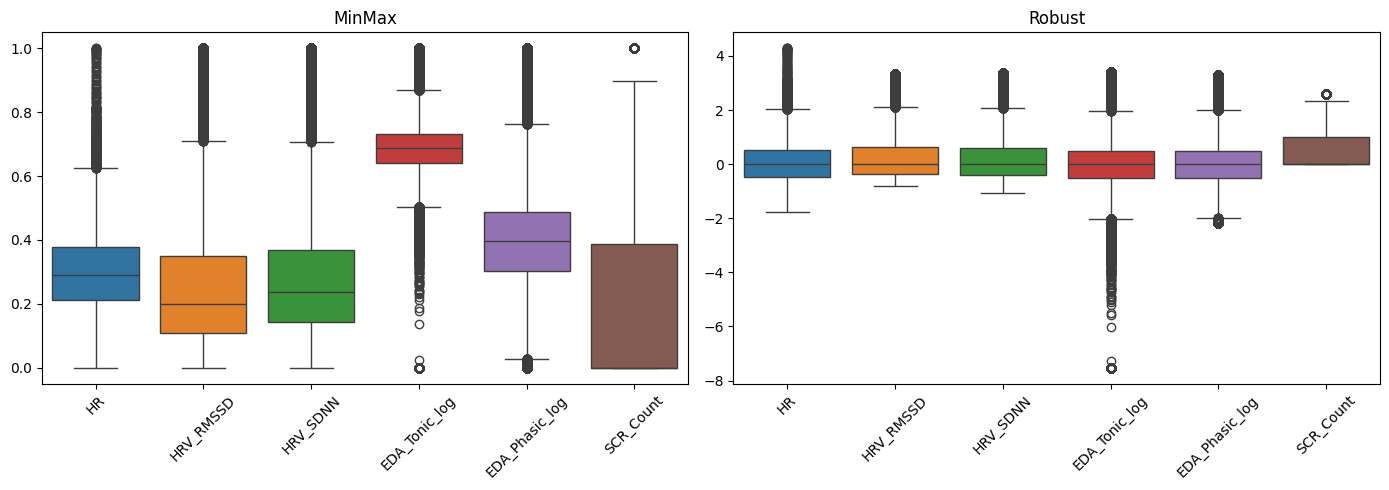

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

df_minmax = pd.DataFrame(X_minmax, columns=features)
df_robust = pd.DataFrame(X_robust, columns=features)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.boxplot(data=df_minmax)
plt.title("MinMax")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.boxplot(data=df_robust)
plt.title("Robust")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
data.describe()
data.to_csv("../data/features_extraction_200HZ_clippinglogupdate.csv", index=False)